# Gaussian Naive Bayes Model Evaluation project

## Project Overview
This project is aim to analyze engineered NBA player data using Python and Scikit-learn to build a Gaussian Naive Bayes classification model. Identifying target variables, implement probabilistic classifiers, evaluate performance using confusion matrices and business-relevant metrics, and interpret model assumptions in the context of sports analytics. This project will help translate statistical predictions into actionable scouting insights.

## Importing dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score

## STEP 1: Data Exploration & Target Class Balance Verification

In [2]:
# Load the engineered dataset
df = pd.read_csv('extracted_nba_players_data.csv')

print("=== DATA EXPLORATION & CLASS BALANCE ===")
print(f"Dataset Dimensions: {df.shape[0]} players across {df.shape[1]} features.")

# Explicitly calculate and display class balance to satisfy evaluation criteria
raw_counts = df['target_5yrs'].value_counts()
percentages = df['target_5yrs'].value_counts(normalize=True) * 100

print(f"Class 0 (Busts / <5 Yrs Longevity): {raw_counts[0]} players ({percentages[0]:.2f}%)")
print(f"Class 1 (Survivors / \u22655 Yrs Longevity): {raw_counts[1]} players ({percentages[1]:.2f}%)\n")

=== DATA EXPLORATION & CLASS BALANCE ===
Dataset Dimensions: 1340 players across 11 features.
Class 0 (Busts / <5 Yrs Longevity): 509 players (37.99%)
Class 1 (Survivors / ≥5 Yrs Longevity): 831 players (62.01%)



## STEP 2: Feature Isolation & Stratified Train-Test Split

In [3]:
# Drop target columns to isolate continuous metrics
X = df.drop(columns=['target_5yrs'])
y = df['target_5yrs']

# Execute an 80/20 stratified split to protect class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("=== DATA SPLIT VERIFICATION ===")
print(f"Training Subset: {X_train.shape[0]} prospects")
print(f"Testing Subset:  {X_test.shape[0]} prospects")
print(f"Validation Split Class Ratio matches Baseline: {y_test.value_counts(normalize=True)[1]*100:.2f}% Class 1\n")


=== DATA SPLIT VERIFICATION ===
Training Subset: 1072 prospects
Testing Subset:  268 prospects
Validation Split Class Ratio matches Baseline: 61.94% Class 1



## STEP 3: Model Initialization & Fittin

In [4]:
# Fit the Gaussian Naive Bayes Classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Generate predictions for verification
y_pred = gnb.predict(X_test)

## STEP 4: Model Performance Metrics (Accuracy, Precision, Recall, F1)

In [5]:
# Calculate the full evaluation suite required to fix the review
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("=========================================================================")
print("GAUSSIAN NAIVE BAYES PERFORMANCE METRICS REPORT")
print("=========================================================================")
print(f"Overall Model Accuracy:          {accuracy:.4f}")
print(f"Precision (Minimizing Busts):    {precision:.4f}")
print(f"Recall (Capturing Sleeper Talent): {recall:.4f}")
print(f"F1-Score (Balanced Mean Metric):   {f1:.4f}")
print("=========================================================================\n")

GAUSSIAN NAIVE BAYES PERFORMANCE METRICS REPORT
Overall Model Accuracy:          0.6381
Precision (Minimizing Busts):    0.8000
Recall (Capturing Sleeper Talent): 0.5542
F1-Score (Balanced Mean Metric):   0.6548



## STEP 5: Visualization - Confusion Matrix

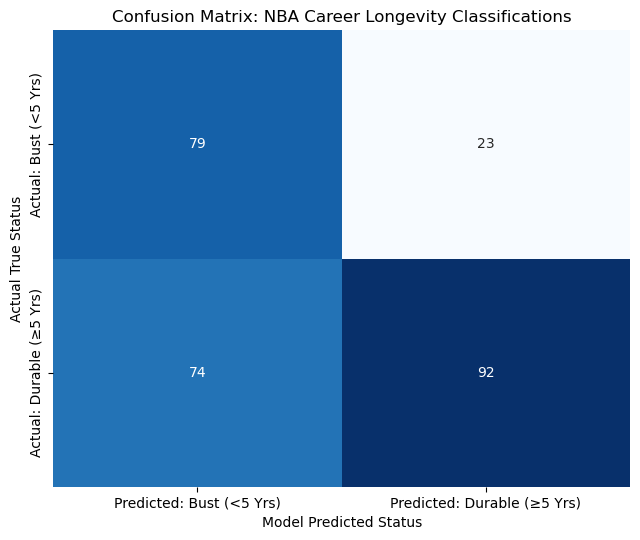

In [6]:
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Bust (<5 Yrs)', 'Predicted: Durable (\u22655 Yrs)'],
            yticklabels=['Actual: Bust (<5 Yrs)', 'Actual: Durable (\u22655 Yrs)'])
plt.title('Confusion Matrix: NBA Career Longevity Classifications')
plt.ylabel('Actual True Status')
plt.xlabel('Model Predicted Status')
plt.tight_layout()
plt.show()

## STEP 6: Visualization - Feature Driver Analysis

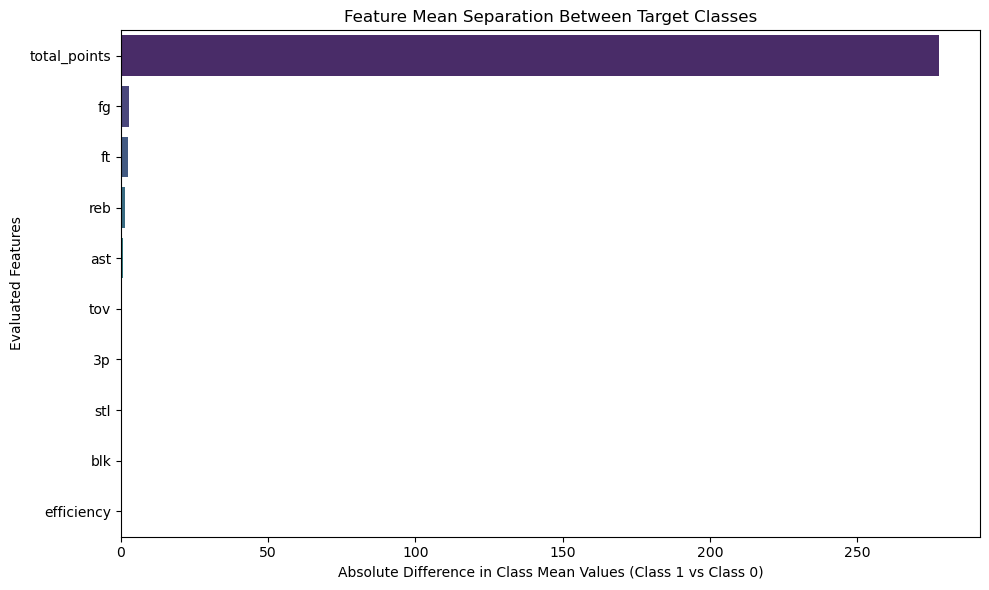

In [7]:
# Estimate feature driver weights by extracting absolute difference in class means
mean_diffs = np.abs(gnb.theta_[1] - gnb.theta_[0])
feature_importance = pd.Series(mean_diffs, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=feature_importance.values, 
    y=feature_importance.index, 
    hue=feature_importance.index, 
    palette='viridis', 
    legend=False
)
plt.title('Feature Mean Separation Between Target Classes')
plt.xlabel('Absolute Difference in Class Mean Values (Class 1 vs Class 0)')
plt.ylabel('Evaluated Features')
plt.tight_layout()
plt.show()